In [86]:
import numpy as np

# Parameters
n = 328  # Number of lines to skip
N = 200  # Number of lines to read

# File name
file_name = "logs/log.amine_polymers"

# Read the file
with open(file_name, 'r') as file:
    # Skip the first n lines
    for _ in range(n):
        next(file)
    print(f"Skipped {n} lines.")
    # print(f"First line after skipping: {file.readline().strip()}")
    # file.seek(0)  # Reset file pointer to the beginning
    
    # Read the next N lines and convert to numpy array column-wise
    data = np.array([list(map(float, next(file).strip().split())) for _ in range(N)]).T

# print(data[:5])
print(np.mean(data, axis=1))  # mean of each column
print(np.std(data, axis=1))   # std deviation of each column

Skipped 328 lines.
[ 2.00500000e+04  9.99448577e-01 -1.38480559e-01  5.58240295e-01
  1.91438966e+00  2.38500942e-04]
[5.77343052e+03 4.55283440e-02 7.51098870e-02 6.04734940e-02
 8.38226557e-02 1.01761652e-03]


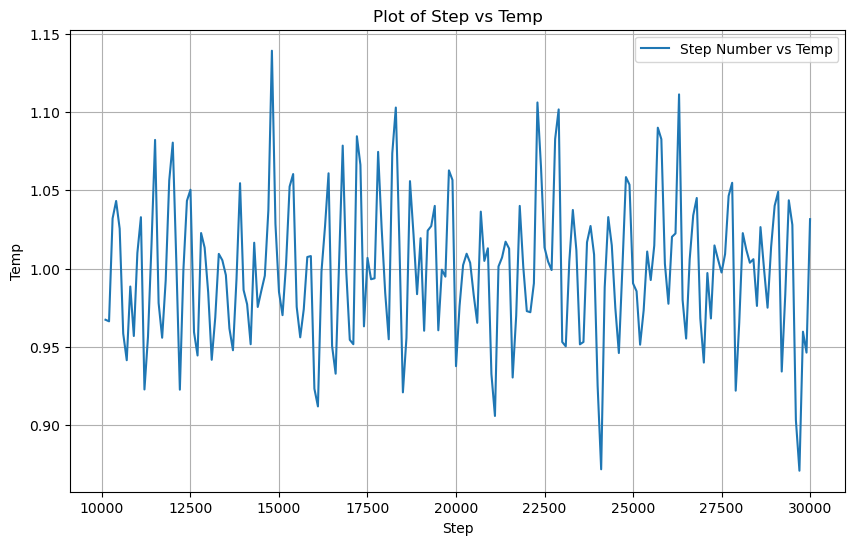

In [77]:
import matplotlib.pyplot as plt

# Plot the data
plt.figure(figsize=(10, 6))
plt.plot(data[0], data[1], label='Step Number vs Temp')
plt.xlabel('Step')
plt.ylabel('Temp')
plt.title('Plot of Step vs Temp')
plt.legend()
plt.grid()
plt.show()

In [145]:
def calc_diff_coeff(logfile, skip_lines, bin_size=1000, slope_method=True):
    """
    Calculate the diffusion coefficient from a LAMMPS MSD log file.

    Parameters:
        logfile (str): Path to the LAMMPS log file. Format is two columns: timesteps and MSD.
        skip_lines (int): Number of header lines to skip.
        bin_size (int): Number of values per group to fit linearly to.
    """
    # Read the file
    data = np.loadtxt(logfile, skiprows=skip_lines)
    # Calculate the diffusion coefficient
    if slope_method:
        # Fit a line to the MSD data in bins of size bin_size
        num_bins = data.shape[0] // bin_size
        slopes = []
        for i in range(num_bins):
            start = i * bin_size
            end = start + bin_size
            if end > data.shape[0]:
                break
            # Fit a line to the data in this bin
            coeffs = np.polyfit(data[start:end, 0], data[start:end, 1], 1)
            slopes.append(coeffs[0])
        # Average the slopes and calculate the diffusion coefficient
        # avg_slope = np.mean(slopes)
        diffusion_coefficient = np.array(slopes) / 6
    else:
        diffusion_coefficient = data[:, 1] / (6 * data[:, 0])
    return diffusion_coefficient

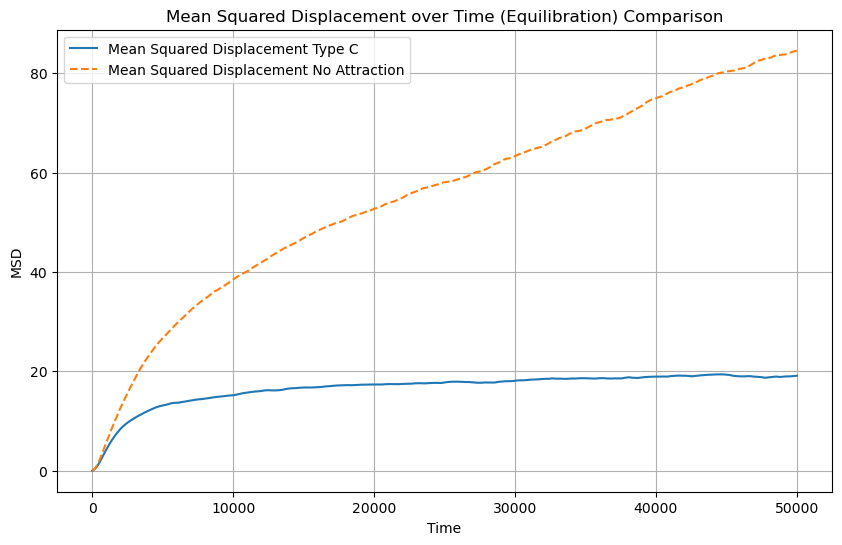

In [146]:
file = 'logs/msd_vector_equil_C.dat'
data_C = np.loadtxt(file, skiprows=2)  # skip the header row
file = 'logs/msd_vector_equil_no_attraction.dat'
data_no_attraction = np.loadtxt(file, skiprows=2) 
# file = 'logs/msd_vector_equil.dat'
# data = np.loadtxt(file, skiprows=2)

plt.figure(figsize=(10, 6))
plt.plot(data_C[:, 0], data_C[:, 1], label='Mean Squared Displacement Type C')
plt.plot(data_no_attraction[:, 0], data_no_attraction[:, 1], linestyle='--', label='Mean Squared Displacement No Attraction')
# plt.plot(data[:, 0], data[:, 1], label='Temp')
plt.xlabel('Time')
plt.ylabel('MSD')
plt.title('Mean Squared Displacement over Time (Equilibration) Comparison')
plt.legend()
plt.grid()
plt.show()


/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_50718/1785208006.py:4: RuntimeWarning: invalid value encountered in divide
  diffusion_coefficient_no_attraction_direct = data_no_attraction[:, 1] / (6 * data_no_attraction[:, 0])
/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_50718/1785208006.py:5: RuntimeWarning: invalid value encountered in divide
  diffusion_coefficient_C_direct = data_C[:, 1] / (6 * data_C[:, 0])


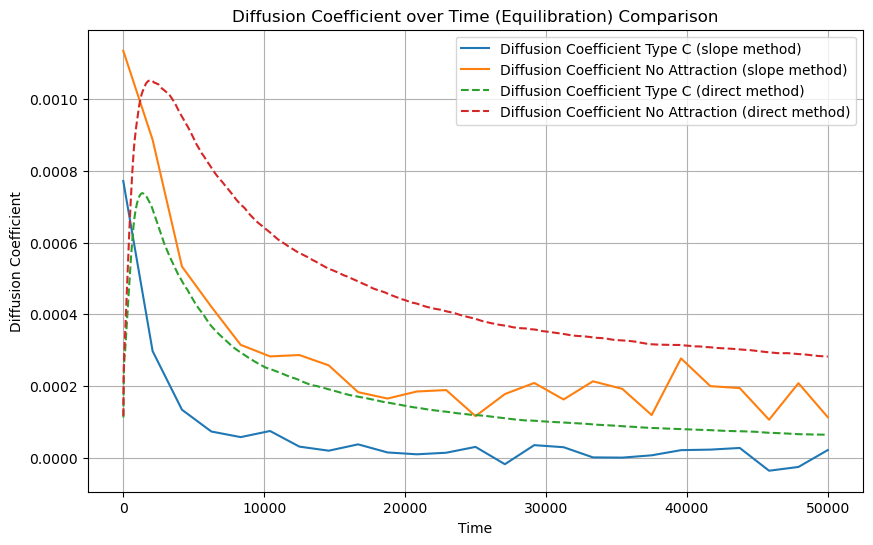

In [165]:
# diffusion_coefficient_C = data_C[:, 1] / (6 * data_C[:, 0])
diffusion_coefficient_C = calc_diff_coeff('logs/msd_vector_equil_C.dat', skip_lines=2, bin_size=200, slope_method=True)
diffusion_coefficient_no_attraction = calc_diff_coeff('logs/msd_vector_equil_no_attraction.dat', skip_lines=2, bin_size=200, slope_method=True)
diffusion_coefficient_no_attraction_direct = data_no_attraction[:, 1] / (6 * data_no_attraction[:, 0])
diffusion_coefficient_C_direct = data_C[:, 1] / (6 * data_C[:, 0])
# Plot the diffusion coefficient as a function of time
plt.figure(figsize=(10, 6))
plt.plot(np.linspace(data_C[0, 0], data_C[-1, 0], len(diffusion_coefficient_C)), diffusion_coefficient_C, label='Diffusion Coefficient Type C (slope method)')
plt.plot(np.linspace(data_no_attraction[0, 0], data_no_attraction[-1, 0], len(diffusion_coefficient_no_attraction)), diffusion_coefficient_no_attraction, label='Diffusion Coefficient No Attraction (slope method)')
plt.plot(data_C[:, 0], diffusion_coefficient_C_direct, linestyle='--', label='Diffusion Coefficient Type C (direct method)')
plt.plot(data_no_attraction[:, 0], diffusion_coefficient_no_attraction_direct, linestyle='--', label='Diffusion Coefficient No Attraction (direct method)')
plt.xlabel('Time')
plt.ylabel('Diffusion Coefficient')
plt.title('Diffusion Coefficient over Time (Equilibration) Comparison')
plt.legend()
plt.grid()
plt.show()


[ 7.71628213e-04  2.97052522e-04  1.33437500e-04  7.26634853e-05
  5.70588502e-05  7.41395047e-05  3.05179629e-05  1.91661467e-05
  3.68654879e-05  1.42855246e-05  9.10468137e-06  1.34745344e-05
  2.97432061e-05 -1.85315183e-05  3.46405298e-05  2.88713430e-05
  4.81367034e-07 -1.47189930e-07  6.26165029e-06  2.06906023e-05
  2.21674079e-05  2.67966337e-05 -3.67161704e-05 -2.61906060e-05
  2.09132003e-05]


/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_50718/2647281132.py:5: RuntimeWarning: invalid value encountered in log10
  log_diff_C = np.log10(diffusion_coefficient_C)


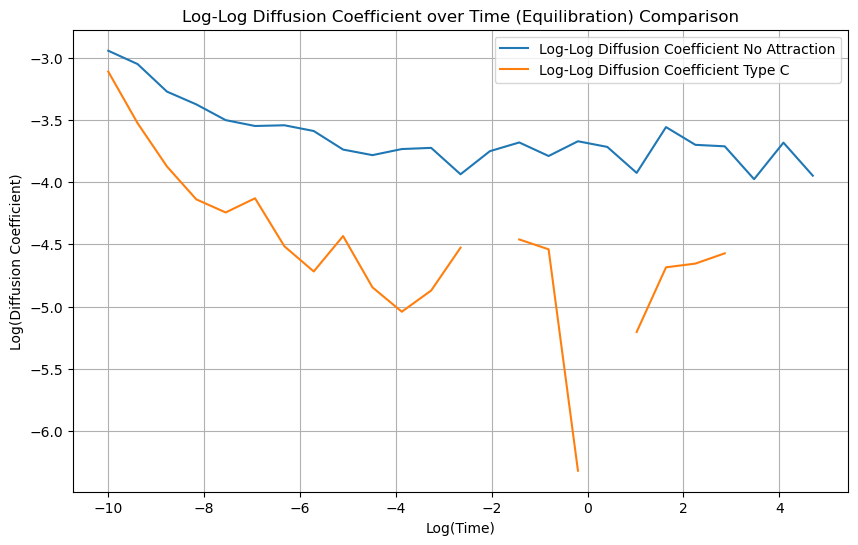

In [166]:
# log-log plot
# print(diffusion_coefficient_no_attraction)
print(diffusion_coefficient_C)
log_diff_no_attraction = np.log10(diffusion_coefficient_no_attraction)
log_diff_C = np.log10(diffusion_coefficient_C)
log_time_C = np.log10(data_C[:, 0] + 1e-10)  # add small value to avoid log(0)
log_time_no_attraction = np.log10(data_no_attraction[:, 0] + 1e-10)  # add small value to avoid log(0)
plt.figure(figsize=(10, 6))
plt.plot(np.linspace(log_time_no_attraction[0], log_time_no_attraction[-1], len(log_diff_no_attraction)), log_diff_no_attraction, label='Log-Log Diffusion Coefficient No Attraction')
plt.plot(np.linspace(log_time_C[0], log_time_C[-1], len(log_diff_C)), log_diff_C, label='Log-Log Diffusion Coefficient Type C')

plt.xlabel('Log(Time)')
plt.ylabel('Log(Diffusion Coefficient)')
plt.title('Log-Log Diffusion Coefficient over Time (Equilibration) Comparison')
plt.legend()
plt.grid()
plt.show()

In [141]:
file = 'logs/msd_vector_equil.dat'
data = np.loadtxt(file, skiprows=2)  # skip the header row

plt.figure(figsize=(10, 6))
plt.plot(data[:, 0], data[:, 1], label='Mean Squared Displacement')
plt.xlabel('Time')
plt.ylabel('MSD')
plt.title('Mean Squared Displacement over Time (Equilibration) No Attraction')
plt.legend()
plt.grid()
plt.show()


FileNotFoundError: logs/msd_vector_equil.dat not found.

/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_50718/1171108648.py:1: RuntimeWarning: divide by zero encountered in divide
  diffusion_coefficient = data[:, 1] / (6 * data[:, 0])


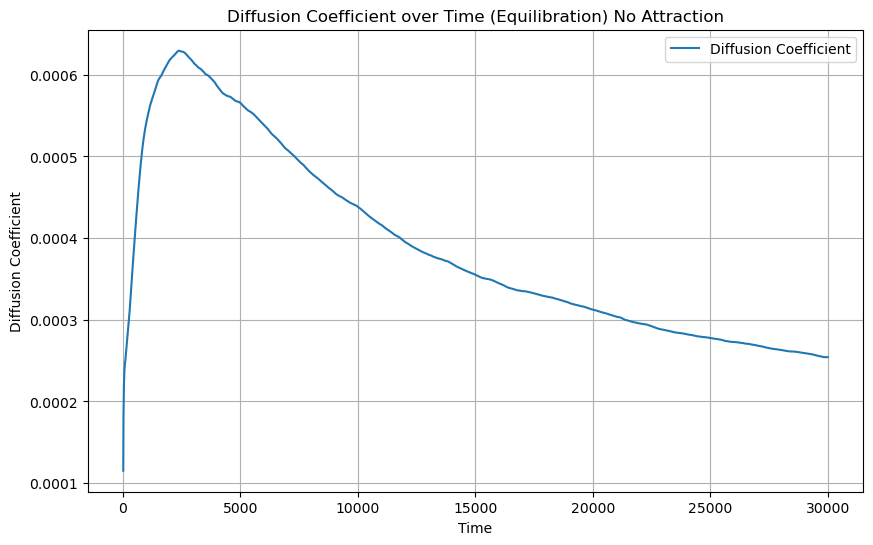

In [99]:
diffusion_coefficient = data[:, 1] / (6 * data[:, 0])
# Plot the diffusion coefficient as a function of time
plt.figure(figsize=(10, 6))
plt.plot(data[:, 0], diffusion_coefficient, label='Diffusion Coefficient')
plt.xlabel('Time')
plt.ylabel('Diffusion Coefficient')
plt.title('Diffusion Coefficient over Time (Equilibration) No Attraction')
plt.legend()
plt.grid()
plt.show()


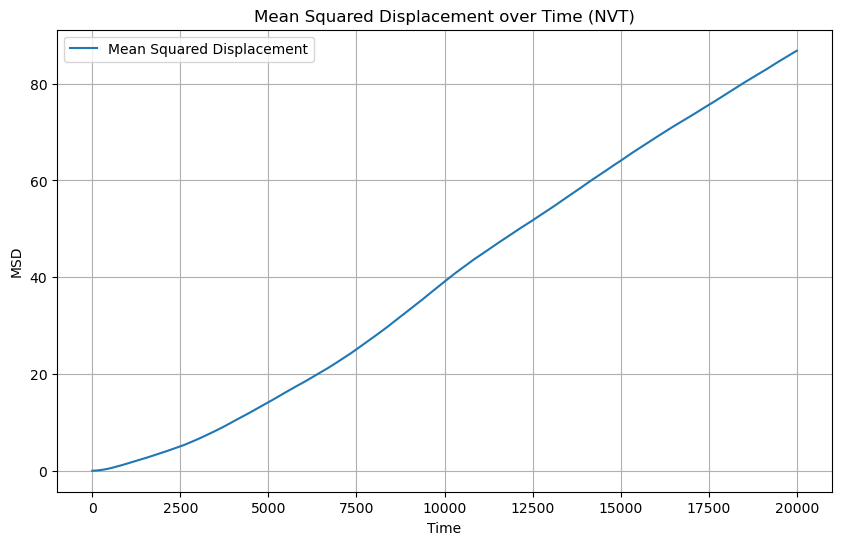

In [ ]:
file = 'logs/msd_vector_nvt.dat'
data = np.loadtxt(file, skiprows=2)  # skip the header row

plt.figure(figsize=(10, 6))
plt.plot(data[:, 0], data[:, 1], label='Mean Squared Displacement')
plt.xlabel('Time')
plt.ylabel('MSD')
plt.title('Mean Squared Displacement over Time (NVT)')
plt.legend()
plt.grid()
plt.show()



/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_50718/4093020744.py:1: RuntimeWarning: invalid value encountered in divide
  diffusion_coefficient = data[:, 1] / (6 * data[:, 0])


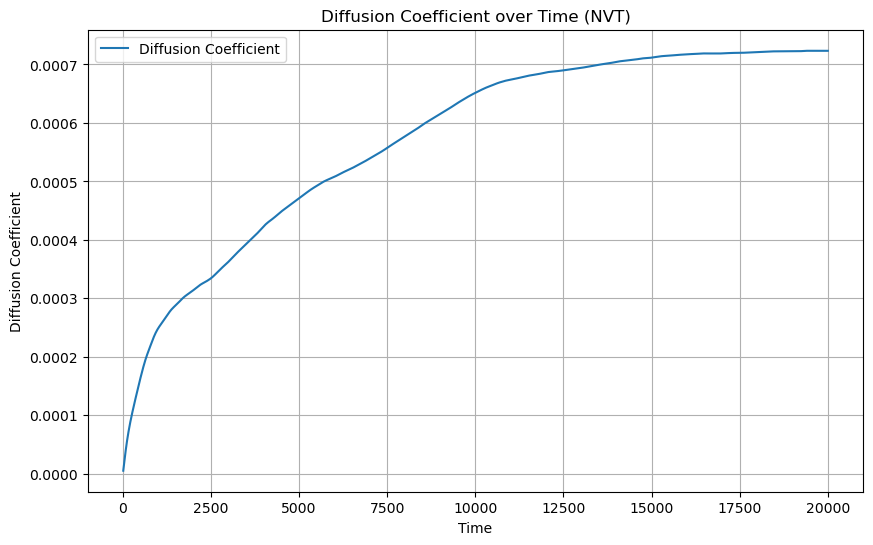

In [52]:
diffusion_coefficient = data[:, 1] / (6 * data[:, 0])
# Plot the diffusion coefficient as a function of time
plt.figure(figsize=(10, 6))
plt.plot(data[:, 0], diffusion_coefficient, label='Diffusion Coefficient')
plt.xlabel('Time')
plt.ylabel('Diffusion Coefficient')
plt.title('Diffusion Coefficient over Time (NVT)')
plt.legend()
plt.grid()
plt.show()


/var/folders/7c/rz9w593n1z33rs4znx4mbl_40000gn/T/ipykernel_50718/1778724011.py:10: RuntimeWarning: invalid value encountered in divide
  diffusion_coefficient = data_combined[:, 1] / (6 * data_combined[:, 0])


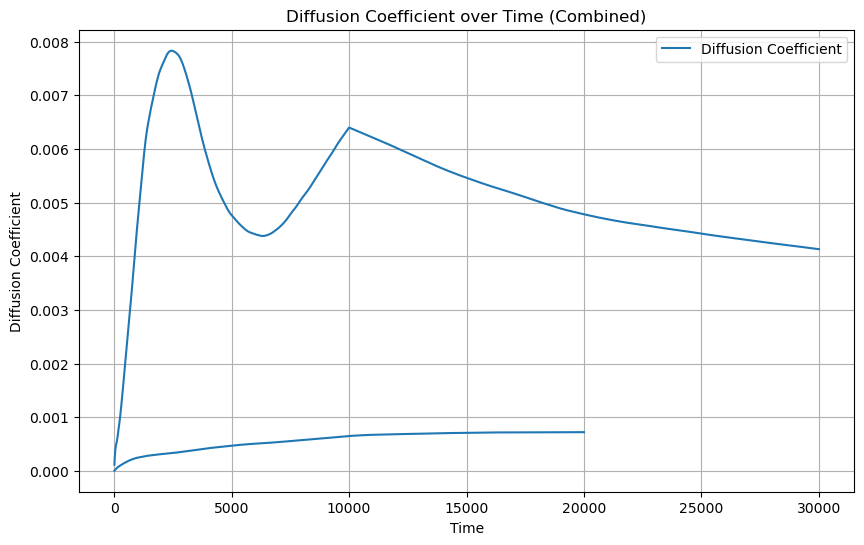

In [ ]:
# combined

data_equil = np.loadtxt('logs/msd_vector_equil.dat', skiprows=2)
# data_nvt = np.loadtxt('logs/msd_vector_nvt.dat', skiprows=2)

# data_nvt[:, 0] += data_equil[-1, 0]  # Adjust time in NVT data to continue from equilibration

# data_combined = np.vstack((data_equil, data_nvt))

diffusion_coefficient = data_combined[:, 1] / (6 * data_combined[:, 0])
# Plot the diffusion coefficient as a function of time
plt.figure(figsize=(10, 6))
plt.plot(data_combined[:, 0], diffusion_coefficient, label='Diffusion Coefficient')
plt.xlabel('Time')
plt.ylabel('Diffusion Coefficient')
plt.title('Diffusion Coefficient over Time (Combined)')
plt.legend()
plt.grid()
plt.show()
